<a href="https://colab.research.google.com/github/ayushman-c/kaggle-notebooks/blob/main/Linear_Regression/ExternalDatasetMLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

df = pd.read_csv("/content/Student_Performance.csv")

#dataset link : https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [44]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


<Axes: >

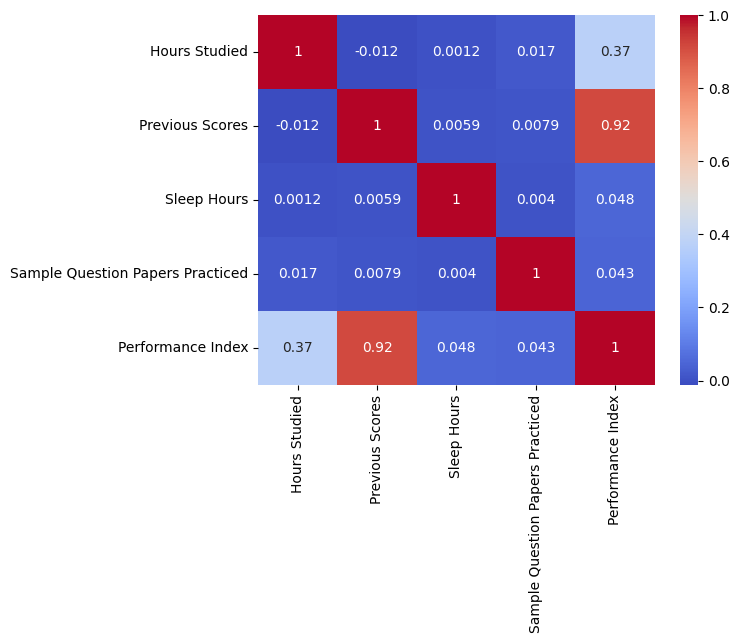

In [45]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

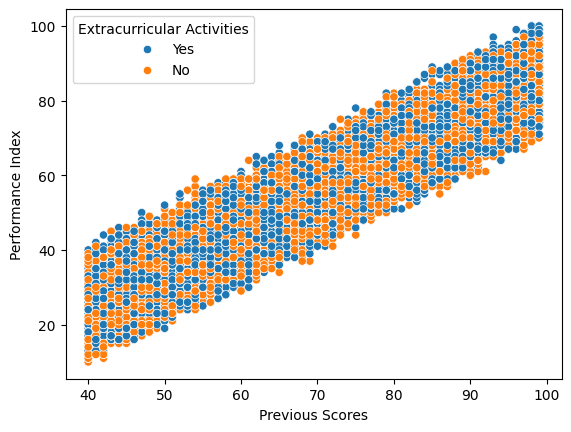

In [46]:
sns.scatterplot(df,x="Previous Scores",y="Performance Index",hue="Extracurricular Activities")

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

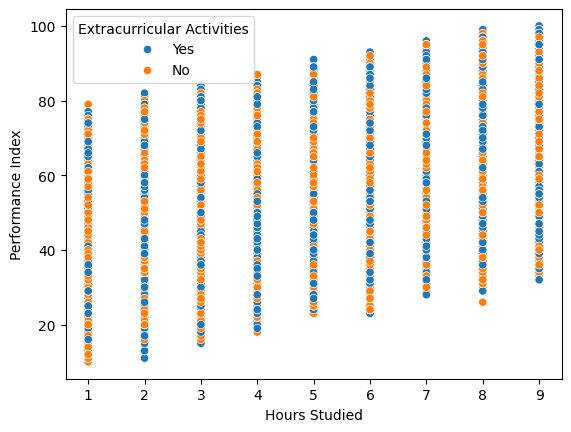

In [47]:
sns.scatterplot(df,x="Hours Studied",y="Performance Index",hue="Extracurricular Activities")

In [48]:
#Factors affecting performance index are Hours Studied and Previous Scores

#Taking 2 factors as input and the permormance index as the targets

# The variable 'df' is a tuple (X, y) in the kernel state, which does not support DataFrame-style slicing (df[:,0]).
# To create the 'new_df' with 'Hours Studied', 'Previous Scores', and 'Performance Index',
# we should concatenate the 'X' DataFrame and 'y' Series, which are already defined.
new_df = pd.concat([X, y], axis=1)

print(new_df.head())

   Hours Studied  Previous Scores  Performance Index
0              7               99               91.0
1              4               82               65.0
2              8               51               45.0
3              5               52               36.0
4              7               75               66.0


In [49]:
fig = px.scatter_3d(
    new_df,
    x='Hours Studied',
    y='Previous Scores',
    z='Performance Index',
    color='Performance Index'
)
fig.show()

In [50]:
X,y = new_df.iloc[:,:-1],new_df.iloc[:,-1]

print(X)
print(y)

      Hours Studied  Previous Scores
0                 7               99
1                 4               82
2                 8               51
3                 5               52
4                 7               75
...             ...              ...
9995              1               49
9996              7               64
9997              6               83
9998              9               97
9999              7               74

[10000 rows x 2 columns]
0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64


In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [57]:
print(X_train.shape)
print(X_test.shape)

(8000, 2)
(2000, 2)


In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [53]:
y_pred = lr.predict(X_test)

In [55]:
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

1.836154792836081
0.9856338039482546
5.3466352197918585
